In [1]:
from transformers import AutoTokenizer
import json
from datasets import Dataset
import numpy as np
from skmultilearn.model_selection import iterative_train_test_split

In [2]:
file_path1 = "stratified_test_data.json"  # Update with your actual file path
with open(file_path1, "r") as f:
    data1 = json.load(f)
file_path2 = "stratified_train_data.json"  # Update with your actual file path
with open(file_path2, "r") as f:
    data2 = json.load(f)

In [3]:
len(data2)

914

In [4]:
len(data1)

230

In [5]:
data_all = data1 + data2
len(data_all)

1144

In [6]:
from transformers import BertTokenizer
# Load the BERT tokenizer (using 'bert-base-uncased' as an example)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
words = []
tokens = []
for d in data_all:
    words.append(len(d["text"].split()))
    tokens.append(len(tokenizer.tokenize(d["text"])))
    


In [7]:
max(words)

212

In [8]:
sum(words)

40188

In [9]:
max(tokens)




416

In [10]:
sum(tokens)

55610

In [11]:
import numpy as np
np.array(words).mean() 


35.12937062937063

In [12]:
np.array(words).std()

29.318942615779804

In [13]:
np.array(tokens).mean() 

48.61013986013986

In [14]:
np.array(tokens).std()

41.60545749042344

In [15]:
from collections import defaultdict
code_dict = defaultdict(int)
subcode_dict = defaultdict(int)
combo_dict = defaultdict(int)
for d in data_all:
    for label in d["labels"]:
        code = label.split("_")[0]
        code_dict[code] += 1
        subcode = label.split("_")[1]
        if subcode != "None":
            subcode_dict[subcode] += 1
        if subcode == "None":
            combo_dict[code] += 1
        else:
            combo_dict[label] += 1
        

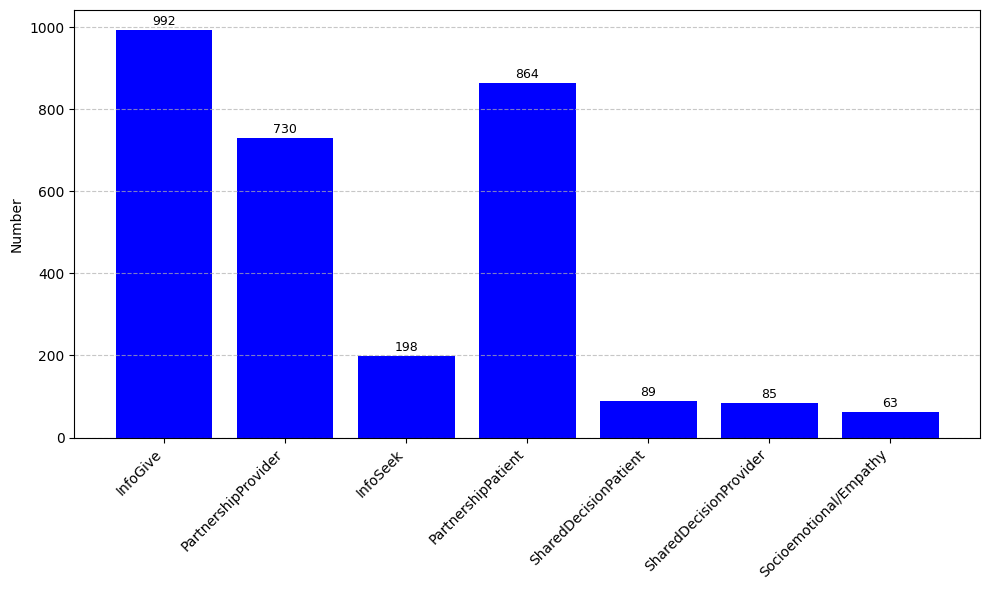

In [16]:
import matplotlib.pyplot as plt
# Unpack dict into categories and counts
def get_plot(counts_dict, name):
    categories = list(counts_dict.keys())
    counts = list(counts_dict.values())
    
    # Create the bar plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(categories, counts, color='blue')
    
    # Add counts on top of bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 5, str(count),
                 ha='center', va='bottom', fontsize=9)
    
    plt.ylabel("Number")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    plt.savefig(name + "bar_plot.svg", format='svg') 
    plt.show()
get_plot(code_dict, "code")

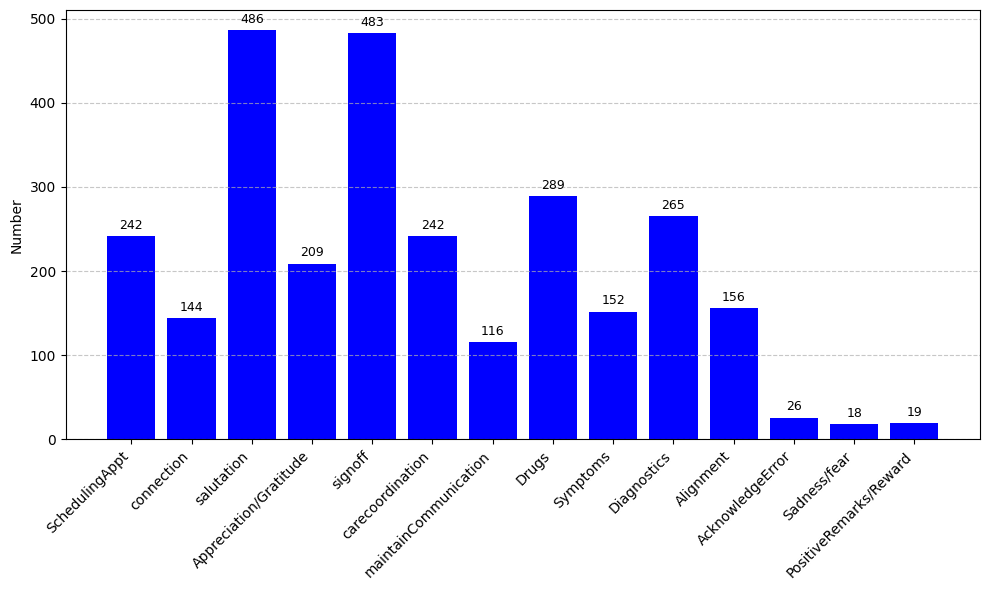

In [17]:
get_plot(subcode_dict, "subcode")

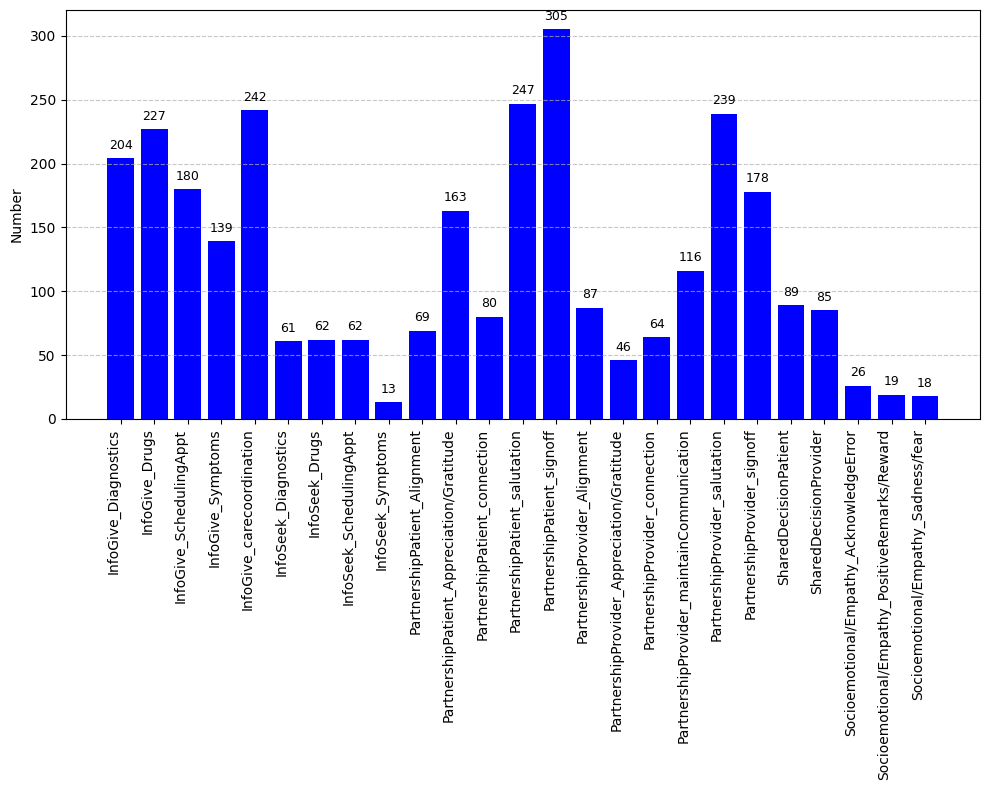

In [18]:
def get_plot2(counts_dict, name):
    categories = sorted(list(counts_dict.keys()))
    #counts = list(counts_dict.values())
    counts = [counts_dict[k] for k in categories]
    # Create the bar plot
    plt.figure(figsize=(10, 8))
    bars = plt.bar(categories, counts, color='blue')
    
    # Add counts on top of bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 5, str(count),
                 ha='center', va='bottom', fontsize=9)
    
    plt.ylabel("Number")
    plt.xticks(rotation=90, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    plt.savefig(name + "bar_plot.svg", format='svg') 
    plt.show()
get_plot2(combo_dict, "combo")

In [14]:
patient = 0
provider = 0
for d in data_all:
    if "From Provider:" in d["text"]:
        provider += 1
    elif "From Patient:" in d["text"]:
        patient += 1
    else:
        raise Exception("error")
        

In [15]:
provider

468

In [16]:
patient

676

In [6]:
data1[0]

{'text': "From Provider: Hi there, 1) He definitely needs/ an appt to review the PET scan with Dr. Person1, Im sorry that wasn't set up earlier, we can set something up for MM/DD/YYYY. In person or telemed? 2) Also , Dr. Person1 would be happy to see you to r/o hemachromatosis, let me know/IS if you need help getting an appt Person2",
 'labels': ['InfoGive_SchedulingAppt',
  'PartnershipProvider_connection',
  'PartnershipProvider_salutation']}

In [10]:
train_data = []
test_data = []

to_remove = ["From Provider:", "From Patient:"]
for data in data1:
    txt = data["text"]
    for tr in to_remove:
        if tr in txt:
            txt = txt.replace(tr, "")
    test_data.append({"text": txt, "labels": data["labels"]})
print (f" lenght of test is {len(test_data)}")

for data in data2:
    txt = data["text"]
    for tr in to_remove:
        if tr in txt:
            txt = txt.replace(tr, "")
    train_data.append({"text": txt, "labels": data["labels"]})
print (f" lenght of test is {len(train_data)}")

 lenght of test is 230
 lenght of test is 914


In [13]:
with open("stratified_train_data_no_pinfo.json", "w") as f:
    json.dump(train_data, f, indent=4)

with open("stratified_test_data_no_pinfo.json", "w") as f:
    json.dump(test_data, f, indent=4)

In [6]:
file_path1 = "../message_dataset_0505.jsonl"  # Update with your actual file path
with open(file_path1, "r") as f:
    data1 = [json.loads(line) for line in f]
file_path2 = "../message_trainset_0617_2.jsonl"  # Update with your actual file path
with open(file_path2, "r") as f:
    data2 = [json.loads(line) for line in f]

In [7]:
data1[1]

{'context': "Hello Person1! I just set up an appt for me to see Dr. Person2 on Mon. MM/DD/YYYY, 4:30pm. Can Person3 and I make that a combo appt? Or, for Person3, if it's to discuss the test results he / we (Person3 doesn't listen to test results - I do) can do a telephone appt with Dr. Person4   So I am correct to hold off appt with dr. Person5 until PET results are in, yes?  THANK YOU for your help! Person6 (for Person3)\n",
 'annotations': [{'codes': ['InfoGive', 'SchedulingAppt'],
   'end': 36,
   'start': 15,
   'text': 'I just set up an appt'},
  {'start': 91,
   'end': 132,
   'text': 'Can Person3 and I make that a combo appt?',
   'codes': ['InfoSeek', 'SchedulingAppt']},
  {'codes': ['PartnershipPatient', 'statePreferences'],
   'end': 265,
   'start': 150,
   'text': "if it's to discuss the test results he / we (Person3 doesn't listen to test results - I do) can do a telephone appt"},
  {'codes': ['PartnershipPatient', 'Appreciation/Gratitude'],
   'end': 376,
   'start': 367

In [8]:
len(data1 + data2)

1200

In [9]:
from transformers import AutoTokenizer
import json
from datasets import Dataset
import numpy as np
from skmultilearn.model_selection import iterative_train_test_split

# Step 1: Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
raw_data = data1 + data2

chosen_code = [
    "InfoGive",
    "InfoSeek",
    "PartnershipPatient",
    "PartnershipProvider",
    "Socioemotional/Empathy",
    "SharedDecisionPatient",
    "SharedDecisionProvider"
]
chosen_subcode = [
    'AcknowledgeError',
    'Alignment',
    'Appreciation/Gratitude',
    'Diagnostics',
    'Drugs',
    'Sadness/fear',
    'SchedulingAppt',
    'Symptoms',
    'carecoordination',
    'connection',
    'PositiveRemarks/Reward',
    'maintainCommunication',
    'salutation',
    'signoff'
]
chosen_code = set(chosen_code)
chosen_subcode = set(chosen_subcode)


def my_clean(txt):
    txt = txt.strip()
    txt = " ".join(txt.split())
    return txt
# def my_clean_label(txt):
#     if txt == "socioemotionalempathy":
#         return "Socioemotional/Empathy"
#     if txt.lower() == "infoseek":
#         return "InfoSeek"
#     if txt.lower() == "infogive":
#         return "InfoGive"
#     return txt
def my_clean_label(txt):
    if txt == "socioemotionalempathy":
        txt = "Socioemotional/Empathy"
    if txt.lower() == "infoseek":
        txt =  "InfoSeek"
    if txt.lower() == "infogive":
        txt =  "InfoGive"
    if txt.lower() == "saddness/fear":
        txt =  "Sadness/fear"
    if txt == "PositiveRemarks":
        txt =  "PositiveRemarks/Reward"
    if txt.lower() == "symptoms":
        txt =  "Symptoms"
    if txt.lower() == "expressconcern,unease" or txt.lower() == "expressconcern/unease":
        txt =  "expressconcern/unease"
    if txt.lower() == "expressconcern,unease":
        txt =  "expressconcern/unease"
    if txt.lower() == "instruction":
        txt =  "Instruction"
    #if subcode_dict[txt] < 5:
    if txt == 'Requests for Opinion' or txt == 'acknowledgePatientExpertiseKnowledge' or txt == 'EncourageQuestions':
        return None
    if txt not in chosen_code and txt not in chosen_subcode:
        return None
    return txt
sizes = []
for item in raw_data:
    from_whom = "Provider" if item["meta"]["TO_PAT_YN"] == "Y" else "Patient"
    sentence = my_clean(item["context"])
    input_text = f"From {from_whom}: {sentence}"
    sizes.append(len(tokenizer.tokenize(input_text)))

In [14]:
print (f"total number of data {len(raw_data)}")
all_labels = set()
processed = []
for item in raw_data:
    from_whom = "Provider" if item["meta"]["TO_PAT_YN"] == "Y" else "Patient"
    sentence = my_clean(item["context"])
    input_text = f"From {from_whom}: {sentence}"
    label_list = []
    for ann in item.get("annotations"):
        code_main = my_clean_label(ann['codes'][0])
        code_sub = my_clean_label(ann['codes'][1])
        if code_main == "SharedDecisionPatient" or code_main == "SharedDecisionProvider":
            code_sub = "None"
        if code_main is None or code_sub is None:
            continue
        label_list.append(f"{code_main}_{code_sub}")
    if (len(label_list) == 0):
        continue
    all_labels.update(label_list)
    processed.append({"text": input_text, "labels": label_list})

# Step 3: Label Mapping
all_labels = sorted(list(all_labels))
label2id = {label: idx for idx, label in enumerate(all_labels)}
id2label = {idx: label for label, idx in label2id.items()}

# Step 4: Convert labels to binary matrix
def get_label_vector(label_list):
    vec = [0] * len(label2id)
    for label in label_list:
        vec[label2id[label]] = 1
    return vec

X = np.array([entry["text"] for entry in processed]).reshape(-1, 1)
Y = np.array([get_label_vector(entry["labels"]) for entry in processed])

# Step 5: Stratified Split
X_train, Y_train, X_test, Y_test = iterative_train_test_split(X, Y, test_size=0.2)

# Step 6: Reconstruct HF dataset structure
train_data = [{"text": x[0], "labels": [all_labels[i] for i, v in enumerate(y) if v == 1]} for x, y in zip(X_train, Y_train)]
test_data  = [{"text": x[0], "labels": [all_labels[i] for i, v in enumerate(y) if v == 1]} for x, y in zip(X_test, Y_test)]

total number of data 1200


In [15]:
from collections import Counter

def count_labels(dataset):
    counter = Counter()
    for sample in dataset:
        counter.update(sample["labels"])
    return counter

train_counts = count_labels(train_data)
test_counts = count_labels(test_data)

# Display counts side-by-side
print("Label\tTrain\tTest")
for label in all_labels:
    print(f"{label}\t{train_counts[label]}\t{test_counts[label]}")

Label	Train	Test
InfoGive_Diagnostics	162	42
InfoGive_Drugs	182	45
InfoGive_SchedulingAppt	144	36
InfoGive_Symptoms	111	28
InfoGive_carecoordination	194	48
InfoSeek_Diagnostics	49	12
InfoSeek_Drugs	50	12
InfoSeek_SchedulingAppt	50	12
InfoSeek_Symptoms	10	3
InfoSeek_carecoordination	12	4
PartnershipPatient_Alignment	55	14
PartnershipPatient_Appreciation/Gratitude	130	33
PartnershipPatient_connection	63	17
PartnershipPatient_salutation	198	49
PartnershipPatient_signoff	244	61
PartnershipProvider_Alignment	70	17
PartnershipProvider_Appreciation/Gratitude	34	12
PartnershipProvider_connection	51	13
PartnershipProvider_maintainCommunication	89	27
PartnershipProvider_salutation	191	48
PartnershipProvider_signoff	140	38
SharedDecisionPatient_None	70	19
SharedDecisionProvider_None	67	18
Socioemotional/Empathy_AcknowledgeError	21	5
Socioemotional/Empathy_PositiveRemarks/Reward	15	4
Socioemotional/Empathy_Sadness/fear	15	3


In [16]:
import json

with open("stratified_train_data.json", "w") as f:
    json.dump(train_data, f, indent=4)

with open("stratified_test_data.json", "w") as f:
    json.dump(test_data, f, indent=4)

In [ ]:
from transformers import AutoTokenizer
import json
from datasets import Dataset

def encode_labels(example):
    label_vector = [0] * len(label2id)
    for label in example["labels"]:
        label_vector[label2id[label]] = 1
    example["label_vector"] = label_vector
    return example

dataset = Dataset.from_list(processed)
dataset = dataset.map(encode_labels)

def tokenize_fn(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Load your dataset
with open("../sentence_trainset_0617_2.json", "r") as f:
    raw_data = json.load(f)

# Build label space
all_labels = set()
processed = []
for item in raw_data:
    from_whom = "Provider" if item["meta"]["TO_PAT_YN"] == "Y" else "Patient"
    sentence = item["context"]
    input_text = f"From {from_whom}: {sentence}"

    label_list = [f"{ann['codes'][0]}_{ann['codes'][1]}" for ann in item.get("annotations", [])]
    all_labels.update(label_list)
    processed.append({"text": input_text, "labels": label_list})

# Create label-to-id mappings
all_labels = sorted(list(all_labels))
label2id = {label: idx for idx, label in enumerate(all_labels)}
id2label = {idx: label for label, idx in label2id.items()}

tokenized_dataset = dataset.map(tokenize_fn)
tokenized_dataset = tokenized_dataset.remove_columns(["text", "labels"])  # keep only encoded input and label_vector
tokenized_dataset = tokenized_dataset.rename_column("label_vector", "labels")

split = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]
eval_dataset = split["test"]
